# Лабораторна робота №9. Алгоритми на рядках

##### AUTHOR

© Kremliakov Hlib

### Мета

Освоїти низку основних алгоритмів на рядках засобами мови Python.

## Хід роботи

### Завдання

Реалізувати контрольні приклади.

– повторити код, наведений вище для довільних рядків; 

– пояснити асимптотику наївного алгоритму пошуку підрядка; 

– обчислити асимптотичну складність алгоритму стиснення рядка за допомогою 𝑧-функції. 

## Виконання

### Наївний алгоритм пошуку підрядка

Наївний алгоритм посимвольно порівнює шаблон із текстом на кожній позиції.
Складність алгоритму у найгіршому випадку: 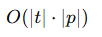

In [1]:
def naive_match(pattern, text):

    # Перевірка довжин
    assert len(pattern) <= len(text)

    occurrences = []

    # Перебір усіх позицій
    for i in range(0, len(text) - len(pattern) + 1):

        match = True

        # Порівняння символів
        for j in range(0, len(pattern)):

            if text[i + j] != pattern[j]:
                match = False
                break

        if match:
            occurrences.append(i)

    return occurrences

### Перевірка роботи наївного алгоритму

In [2]:
text = "needleneedleneedle"
pattern = "needle"

result = naive_match(pattern, text)

print("Позиції входження:")
print(result)

Позиції входження:
[0, 6, 12]


### Реалізація Z-функції

Z-функція для рядка — це масив, де кожен елемент показує довжину найбільшого префікса рядка, який починається з відповідної позиції.

In [3]:
def z_func(s):

    z = [0] * len(s)

    left = 0
    right = 0

    for i in range(1, len(s)):

        if i <= right:
            z[i] = min(right - i + 1, z[i - left])

        while i + z[i] < len(s) and s[z[i]] == s[i + z[i]]:
            z[i] += 1

        if i + z[i] - 1 > right:
            left = i
            right = i + z[i] - 1

    z[0] = len(s)

    return z

### Перевірка роботи Z-функції

In [4]:
string = "abracadabra"

result = z_func(string)

print("Z-функція:")
print(result)

Z-функція:
[11, 0, 0, 1, 0, 1, 0, 4, 0, 0, 1]


### Пошук підрядка за допомогою Z-функції

Алгоритм має складність: 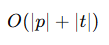

In [5]:
def z_match(pattern, text):

    # Формування нового рядка
    s = pattern + "$" + text

    # Обчислення Z-функції
    z = z_func(s)

    occurrences = []

    # Пошук збігів
    for i in range(len(pattern) + 1, len(s)):

        if z[i] == len(pattern):
            occurrences.append(i - len(pattern) - 1)

    return occurrences

### Перевірка пошуку через Z-функцію

In [6]:
text = "абабагаламага"
pattern = "аб"

result = z_match(pattern, text)

print("Позиції входження:")
print(result)

Позиції входження:
[0, 2]


### Стиснення рядка за допомогою Z-функції

Ідея алгоритму:
- знайти найменший префікс;
- перевірити, чи можна побудувати весь рядок повторенням цього префікса.

In [7]:
def compress_with_z(s):

    z = z_func(s)

    for i in range(1, len(s)):

        if i + z[i] == len(s) and len(s) % i == 0:
            return s[:i]

    return s

### Перевірка стиснення рядка

In [8]:
string = "абырвалгабырвалгабырвалг"

compressed = compress_with_z(string)

print("Стиснений рядок:")
print(compressed)

Стиснений рядок:
абырвалг


## Висновок

У ході лабораторної роботи було:
- реалізовано наївний алгоритм пошуку;
- реалізовано Z-функцію;
- реалізовано пошук підрядка за допомогою Z-функції;
- реалізовано стиснення рядка.

Z-функція дозволяє значно пришвидшити обробку рядків у порівнянні з наївними алгоритмами.

## Контрольні питання

### 1. Що таке префікс-функція?

Префікс-функція — це масив, який показує довжину найбільшого власного префікса, що одночасно є суфіксом для кожного префікса рядка.

На відміну від Z-функції, вона працює з префіксами всередині самого рядка.

### 2. Що таке Z-функція?

Z-функція — це масив, у якому кожен елемент показує довжину найбільшого префікса рядка, що збігається з підрядком, який починається з певної позиції.

Вона використовується для:
- пошуку підрядків;
- аналізу рядків;
- стиснення рядків.

### 3. Підходи до задачі найдовшого спільного підрядка

Основні методи:
- динамічне програмування;
- Z-функція;
- префікс-функція;
- суфіксні масиви;
- суфіксні дерева.

### 4. Де застосовуються алгоритми на рядках?

Алгоритми на рядках використовуються:
- у пошукових системах;
- у текстових редакторах;
- у перевірці орфографії;
- у системах обробки природної мови;
- у біоінформатиці;
- у системах аналізу текстів.